# Oráculo de selección adaptativa de δ — Rediseño y validación
**TFG ML Lattice Cryptanalysis — UC3M, Escuela Politécnica Superior**

## Nota de reproducibilidad

| Componente | Versión |
|---|---|
| Python | 3.12.12 |
| numpy | 2.4.2 |
| scikit-learn | 1.8.0 |
| xgboost | 3.2.0 |
| fpylll | 0.6.4 |
| Hardware (tiempos LLL) | WSL2 / Linux 6.6.87.2 / CPU x86-64 (modelos XGBoost en CPU) |

**Semillas:** `np.random.seed(42)`, `random_state=42` en todos los splits y modelos.  
**Partición:** 80/20 con `random_state=42`, idéntica a `dim_models.ipynb`.  
**Modelos previos requeridos:** `dim_models.ipynb` debe haberse ejecutado antes para generar `models/per_dim/gb_target_rhf_d*.pkl`.

## Estructura del notebook
1. Carga y verificación de modelos y datos
2. **Fase 1** — Diagnóstico del oráculo actual (4 sub-análisis)
3. **Fase 2** — Reformulación: Opción A (regresión residual) y Opción B (clasificación directa)
4. **Fase 3** — Protocolo experimental: baselines y evaluación completa con barrido de τ
5. Validación temporal en retículos frescos
6. Figuras y tablas para la memoria
7. Resumen de hallazgos

## 1. Carga y verificación de modelos y datos

In [1]:
import os, warnings, time, sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, confusion_matrix
from xgboost import XGBRegressor, XGBClassifier
from split_utils import reconstruct_base_id, load_test_base_ids

warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline
plt.rcParams.update({'font.size': 10, 'figure.dpi': 100})

ROOT     = os.getcwd()
DOCS     = os.path.join(ROOT, 'docs', 'oraculo')
MODELS   = os.path.join(ROOT, 'models', 'per_dim')
os.makedirs(DOCS, exist_ok=True)

DIMENSIONS    = [10, 20, 30, 50, 80, 100, 120, 150, 200]
DELTAS        = [0.55, 0.75, 0.90, 0.99]
THRESHOLDS    = [0.0, 0.01, 0.02, 0.03, 0.05, 0.10, 0.20]
LATTICE_TYPES = ['gaussian', 'qary', 'sparse', 'uniform']

FEATURE_COLS_NO_DELTA = [
    'log_det','norm_mean','norm_std','norm_max','norm_min','norm_ratio',
    'gso_mean','gso_std','gso_max','gso_min','gso_ratio','gso_slope','gso_res_std',
    'log_orth_defect','gram_off_diag_mean','gram_off_diag_max',
    'log_cond_num','mu_mean','mu_max','mu_frac_gt_05','std_B',
    'profile_mass','profile_entropy','profile_adjacency',
]
DELTA_TO_IDX = {0.55:0, 0.75:1, 0.90:2, 0.99:3}
IDX_TO_DELTA = {v:k for k,v in DELTA_TO_IDX.items()}
print('Configuración cargada.')

Configuración cargada.


In [2]:
# Verificar modelos per-dim (requisito previo: ejecutar dim_models.ipynb)
missing = [d for d in DIMENSIONS
           if not os.path.exists(os.path.join(MODELS, f'gb_target_rhf_d{d}.pkl'))]
if missing:
    raise FileNotFoundError(
        f'Faltan modelos RHF para d={missing}. Ejecuta dim_models.ipynb primero.')
print(f'OK: modelos RHF per-dim encontrados para {DIMENSIONS}.')

# Verificar dataset
if not os.path.exists(os.path.join(ROOT, 'lattice_dataset_v2.csv')):
    raise FileNotFoundError('lattice_dataset_v2.csv no encontrado.')
print('OK: lattice_dataset_v2.csv encontrado.')

OK: modelos RHF per-dim encontrados para [10, 20, 30, 50, 80, 100, 120, 150, 200].
OK: lattice_dataset_v2.csv encontrado.


In [3]:
# Carga y preparación del dataset
df = pd.read_csv(os.path.join(ROOT, 'lattice_dataset_v2.csv'))

# base_id canónico ANTES de get_dummies → se arrastra a df_enc
df['base_id'] = reconstruct_base_id(df)

df_enc = pd.get_dummies(df, columns=['lattice_type'], drop_first=False)
lt_cols = [c for c in df_enc.columns if c.startswith('lattice_type_')]

# Pivot: una fila por base, columnas = RHF para cada delta
pivot_rhf = df_enc.pivot_table(
    index=['d']+lt_cols+['base_id'], columns='delta', values='target_rhf'
).reset_index()
pivot_rhf.columns.name = None
pivot_rhf['delta_optimal'] = pivot_rhf[[0.55,0.75,0.90,0.99]].idxmin(axis=1)
pivot_rhf['best_rhf']      = pivot_rhf[[0.55,0.75,0.90,0.99]].min(axis=1)

# Features por base (tomamos la fila con delta=0.99 como representativa)
df_ref = df_enc[df_enc['delta']==0.99].copy()
# base_id ya está en df_ref (heredado de df_enc); no se recalcula
df_oracle = df_ref.merge(
    pivot_rhf[['d']+lt_cols+['base_id','delta_optimal','best_rhf']+DELTAS],
    on=['d']+lt_cols+['base_id'])
for lt in LATTICE_TYPES:
    df_oracle.loc[df_oracle[f'lattice_type_{lt}']==1, 'lattice_type_str'] = lt

# Split canónico: mismas bases de test que dim_models / dim_mlps
test_ids = load_test_base_ids()
df_test  = df_oracle[df_oracle['base_id'].isin(test_ids)].copy()
df_train = df_oracle[~df_oracle['base_id'].isin(test_ids)].copy()

# Anti-fuga: verificar que no hay bases compartidas
assert not (set(df_train['base_id']) & set(df_test['base_id'])), "FUGA en oracle split"
# Verificar subset: bases test del oráculo ⊆ test_ids global
assert set(df_test['base_id']) <= test_ids, "df_test contiene bases fuera de test_ids"

print(f'Dataset total: {df.shape}')
print(f'Bases únicas: {len(df_oracle)}')
print(f'Train: {len(df_train)} | Test: {len(df_test)}')
print(f'\nDistribución δ_optimal (test set):')
print(df_test['delta_optimal'].value_counts().sort_index())

Dataset total: (224000, 31)
Bases únicas: 56000
Train: 44800 | Test: 11200

Distribución δ_optimal (test set):
delta_optimal
0.55     911
0.75    1335
0.9     3018
0.99    5936
Name: count, dtype: int64


In [4]:
# Cargar modelos RHF absolutos existentes (entrenados en dim_models.ipynb)
models_rhf, scalers_rhf = {}, {}
for d in DIMENSIONS:
    models_rhf[d]  = joblib.load(os.path.join(MODELS, f'gb_target_rhf_d{d}.pkl'))
    scalers_rhf[d] = joblib.load(os.path.join(MODELS, f'scaler_target_rhf_d{d}.pkl'))
print(f'Modelos RHF cargados: {list(models_rhf.keys())}')

# Cargar clasificadores entrenados en este notebook (Opción B)
models_clf, scalers_clf = {}, {}
for d in DIMENSIONS:
    for tau in THRESHOLDS:
        key = f'clf_delta_d{d}_tau{int(tau*100):03d}'
        mp = os.path.join(MODELS, f'{key}.pkl')
        sp = os.path.join(MODELS, f'scaler_{key}.pkl')
        if os.path.exists(mp):
            models_clf[(d,tau)]  = joblib.load(mp)
            scalers_clf[(d,tau)] = joblib.load(sp)
print(f'Clasificadores δ* cargados: {len(models_clf)} combinaciones (d, τ)')

# Cargar modelos residuales (Opción A)
models_res, scalers_res = {}, {}
for d in DIMENSIONS:
    mp = os.path.join(MODELS, f'gb_delta_residual_d{d}.pkl')
    sp = os.path.join(MODELS, f'scaler_delta_residual_d{d}.pkl')
    if os.path.exists(mp):
        models_res[d]  = joblib.load(mp)
        scalers_res[d] = joblib.load(sp)
print(f'Modelos residuales ΔRHF cargados: {list(models_res.keys())}')

Modelos RHF cargados: [10, 20, 30, 50, 80, 100, 120, 150, 200]
Clasificadores δ* cargados: 36 combinaciones (d, τ)
Modelos residuales ΔRHF cargados: [10, 20, 30, 50, 80, 100, 120, 150, 200]


---
## 2. Fase 1 — Diagnóstico del oráculo actual

El oráculo original compara predicciones absolutas de RHF para cuatro valores de δ y
elige el menor δ tal que `pred(δ) ≤ pred(0,99)·(1+τ)`. Esta sección documenta
cuatro fallos que invalidan ese diseño.

In [5]:
# ── Diagnóstico 1: el umbral τ no tiene efecto en el oráculo absoluto ────────
FEAT_CLF = FEATURE_COLS_NO_DELTA + lt_cols

def oracle_absolute(feat, d, threshold, models, scalers):
    """Oráculo original: compara predicciones absolutas de RHF."""
    preds = {}
    for delta in DELTAS:
        x = np.array(list(feat)+[delta], dtype=float).reshape(1,-1)
        preds[delta] = float(models[d].predict(scalers[d].transform(x))[0])
    ref = preds[0.99]
    for delta in [0.55,0.75,0.90]:
        if preds[delta] <= ref*(1+threshold):
            return delta, preds
    return 0.99, preds

def delta_opt_for_tau(row, tau):
    """δ*(τ): menor δ tal que RHF(δ) ≤ best_RHF·(1+τ)."""
    ref = float(row['best_rhf'])
    for delta in [0.55,0.75,0.90,0.99]:
        if float(row[delta]) <= ref*(1+tau):
            return float(delta)
    return 0.99

# Submuestra para diagnóstico (reproducible)
rng_d = np.random.RandomState(42)
idx_s = rng_d.choice(df_test.index, size=min(2000, len(df_test)), replace=False)
df_diag = df_test.loc[idx_s].copy()

print('Barrido τ — oráculo ABSOLUTO (diseño actual):')
print(f'  {"τ":6s}  {"saved%":8s}  {"acc%":8s}  {"Δq_mean":10s}  {"Δq_P95":10s}')
for thr in THRESHOLDS:
    rows = []
    for _, row in df_diag.iterrows():
        d = int(row['d'])
        feat = row[FEAT_CLF].values.astype(float)
        chosen, _ = oracle_absolute(feat, d, thr, models_rhf, scalers_rhf)
        dst = delta_opt_for_tau(row, thr)
        rows.append({'chosen': chosen, 'dst': dst,
                     'rhf_c': float(row[chosen]), 'rhf_099': float(row[0.99])})
    r = pd.DataFrame(rows)
    r['dq'] = (r['rhf_c']-r['rhf_099'])/r['rhf_099']*100
    print(f'  {thr:.2f}    {r["chosen"].lt(0.99).mean()*100:7.1f}%  '
          f'{(r["chosen"]==r["dst"]).mean()*100:7.1f}%  '
          f'{r["dq"].mean():+9.3f}%  {r["dq"].quantile(0.95):+9.3f}%')

print()
print('CONCLUSIÓN: τ no modifica saved%, acc% ni Δq → oráculo degenerado.')
print('El oráculo siempre elige δ=0.55 porque pred(δ) ≈ cte para toda δ.')

Barrido τ — oráculo ABSOLUTO (diseño actual):
  τ       saved%    acc%      Δq_mean     Δq_P95    
  0.00      100.0%      8.8%     +1.129%     +4.786%
  0.01      100.0%     68.3%     +1.129%     +4.786%
  0.02      100.0%     79.8%     +1.129%     +4.786%
  0.03      100.0%     88.1%     +1.129%     +4.786%
  0.05      100.0%     95.2%     +1.129%     +4.786%
  0.10      100.0%    100.0%     +1.129%     +4.786%
  0.20      100.0%    100.0%     +1.129%     +4.786%

CONCLUSIÓN: τ no modifica saved%, acc% ni Δq → oráculo degenerado.
El oráculo siempre elige δ=0.55 porque pred(δ) ≈ cte para toda δ.


In [6]:
# ── Diagnóstico 2: efecto intra-base de δ vs MAE vs std entre bases ───────
FEAT_WITH_DELTA = FEATURE_COLS_NO_DELTA + lt_cols + ['delta']

intra_rows = []
for d in DIMENSIONS:
    df_d = df_diag[df_diag['d']==d]
    if len(df_d)==0: continue
    scaler, model = scalers_rhf[d], models_rhf[d]
    
    ranges_intra = []
    for _, row in df_d.iterrows():
        feat_base = row[FEATURE_COLS_NO_DELTA+lt_cols].values.astype(float)
        pv = [float(model.predict(scaler.transform(
               np.array(list(feat_base)+[delta], dtype=float).reshape(1,-1)))[0])
              for delta in DELTAS]
        ranges_intra.append(max(pv)-min(pv))
    
    rows_d = df_enc[df_enc['d']==d].copy()
    X_d = rows_d[FEAT_WITH_DELTA].values
    y_d = rows_d['target_rhf'].values
    mae_d = mean_absolute_error(y_d, model.predict(scaler.transform(X_d)))
    std_d = df_d[0.99].std()
    
    intra_rows.append({'d':d,
        'rango_intrabase_medio': np.mean(ranges_intra),
        'MAE_modelo': mae_d,
        'std_entre_bases': std_d})

intra_df = pd.DataFrame(intra_rows)
print('Efecto intra-base de δ en la predicción del modelo RHF:')
print(intra_df.set_index('d').to_string(float_format='{:.6f}'.format))
print()
print('CONCLUSIÓN: el rango intra-base (max_δ pred - min_δ pred) es ~0.')
print('Es comparable o MENOR que el MAE del modelo → comparar predicciones')
print('absolutas entre deltas es comparar ruido del modelo, no señal real.')

Efecto intra-base de δ en la predicción del modelo RHF:
     rango_intrabase_medio  MAE_modelo  std_entre_bases
d                                                      
10                0.000000    0.018417         0.018273
20                0.000000    0.013438         0.006384
30                0.000000    0.011255         0.005481
50                0.000000    0.006446         0.005555
80                0.000000    0.002350         0.006772
100               0.000000    0.001479         0.006824
120               0.000000    0.001148         0.006562
150               0.000000    0.000894         0.005801
200               0.000000    0.000623         0.004541

CONCLUSIÓN: el rango intra-base (max_δ pred - min_δ pred) es ~0.
Es comparable o MENOR que el MAE del modelo → comparar predicciones
absolutas entre deltas es comparar ruido del modelo, no señal real.


In [7]:
# ── Diagnóstico 3: baseline trivial vs oráculo actual ──────────────────────
baseline_099_acc = (df_test['delta_optimal']==0.99).mean()

# Oráculo actual (τ=0.10, target=δ*(0)=delta_optimal)
ora_rows = []
for _, row in df_diag.head(500).iterrows():
    d = int(row['d'])
    feat = row[FEAT_CLF].values.astype(float)
    chosen, _ = oracle_absolute(feat, d, 0.10, models_rhf, scalers_rhf)
    ora_rows.append({'chosen': chosen, 'opt': float(row['delta_optimal'])})
ora_df = pd.DataFrame(ora_rows)
oracle_abs_acc = (ora_df['chosen']==ora_df['opt']).mean()

print(f'Accuracy "siempre δ=0.99":        {baseline_099_acc*100:.1f}%')
print(f'Accuracy oráculo absoluto (τ=0.1): {oracle_abs_acc*100:.1f}%')
print()
print(f'CONCLUSIÓN: el oráculo absoluto ({oracle_abs_acc*100:.1f}%) es PEOR '
      f'que el baseline trivial "siempre δ=0.99" ({baseline_099_acc*100:.1f}%).')

Accuracy "siempre δ=0.99":        53.0%
Accuracy oráculo absoluto (τ=0.1): 10.2%

CONCLUSIÓN: el oráculo absoluto (10.2%) es PEOR que el baseline trivial "siempre δ=0.99" (53.0%).


In [8]:
# ── Diagnóstico 4: distribución de δ_optimal y monotonía ──────────────────
print('Distribución de δ_optimal (56 000 bases únicas):')
dist_all = pivot_rhf['delta_optimal'].value_counts().sort_index()
for dv, cnt in dist_all.items():
    print(f'  δ={dv}: {cnt:6d} bases ({cnt/len(pivot_rhf)*100:.1f}%)')

print(f'\nTotal con δ* ≠ 0.99: {(pivot_rhf["delta_optimal"]!=0.99).sum()} bases '
      f'({(pivot_rhf["delta_optimal"]!=0.99).mean()*100:.1f}%)')

def check_mono(row):
    return row[0.55]>=row[0.75]>=row[0.90]>=row[0.99]
mono_pct = pivot_rhf.apply(check_mono, axis=1).mean()
print(f'\n% bases con monotonía estricta RHF(0.55)≥...≥RHF(0.99): {mono_pct*100:.1f}%')
print('La no-monotonía (17.7%) puede deberse a ruido de precisión finita de LLL')
print('o a dependencias no lineales del proceso de reducción.')

# Distribución de δ*(τ) según τ
print('\nDistribución de δ*(τ) según τ (% bases con cada δ):')
for tau_v in THRESHOLDS:
    dstar_dist = pivot_rhf.apply(lambda r: delta_opt_for_tau(r, tau_v), axis=1)
    vc = dstar_dist.value_counts().sort_index()
    parts = [f'δ={dv}: {cnt/len(pivot_rhf)*100:.1f}%' for dv, cnt in vc.items()]
    print(f'  τ={tau_v}: {" | ".join(parts)}')

Distribución de δ_optimal (56 000 bases únicas):
  δ=0.55:   4563 bases (8.1%)
  δ=0.75:   6744 bases (12.0%)
  δ=0.9:  15088 bases (26.9%)
  δ=0.99:  29605 bases (52.9%)

Total con δ* ≠ 0.99: 26395 bases (47.1%)

% bases con monotonía estricta RHF(0.55)≥...≥RHF(0.99): 82.3%
La no-monotonía (17.7%) puede deberse a ruido de precisión finita de LLL
o a dependencias no lineales del proceso de reducción.

Distribución de δ*(τ) según τ (% bases con cada δ):
  τ=0.0: δ=0.55: 8.1% | δ=0.75: 12.0% | δ=0.9: 26.9% | δ=0.99: 52.9%
  τ=0.01: δ=0.55: 69.4% | δ=0.75: 15.3% | δ=0.9: 14.2% | δ=0.99: 1.1%
  τ=0.02: δ=0.55: 80.3% | δ=0.75: 15.9% | δ=0.9: 3.8% | δ=0.99: 0.0%
  τ=0.03: δ=0.55: 88.5% | δ=0.75: 10.7% | δ=0.9: 0.8%
  τ=0.05: δ=0.55: 96.0% | δ=0.75: 3.9% | δ=0.9: 0.1%
  τ=0.1: δ=0.55: 99.9% | δ=0.75: 0.1%
  τ=0.2: δ=0.55: 100.0%


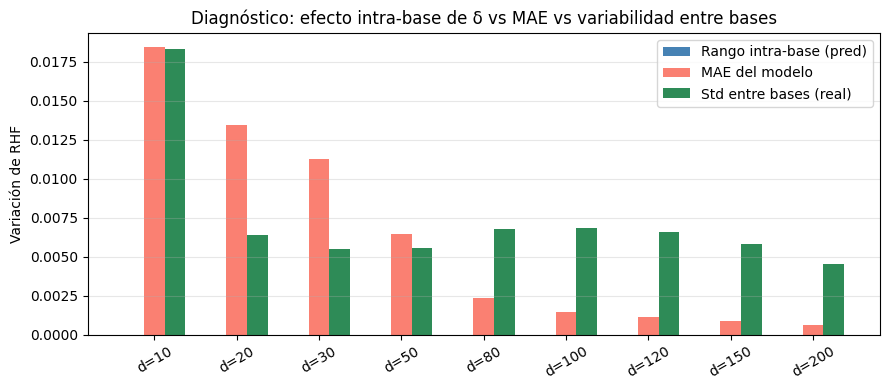

Figura guardada en docs/oraculo/diag_efecto_intrabase.png


In [9]:
# Figura diagnóstico: efecto intra-base
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(intra_df))
w = 0.25
ax.bar(x-w, intra_df['rango_intrabase_medio'], w, label='Rango intra-base (pred)', color='steelblue')
ax.bar(x,   intra_df['MAE_modelo'],            w, label='MAE del modelo',          color='salmon')
ax.bar(x+w, intra_df['std_entre_bases'],       w, label='Std entre bases (real)',   color='seagreen')
ax.set_xticks(x); ax.set_xticklabels([f'd={d}' for d in intra_df['d']], rotation=30)
ax.set_ylabel('Variación de RHF'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Diagnóstico: efecto intra-base de δ vs MAE vs variabilidad entre bases')
plt.tight_layout()
plt.savefig(os.path.join(DOCS,'diag_efecto_intrabase.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en docs/oraculo/diag_efecto_intrabase.png')

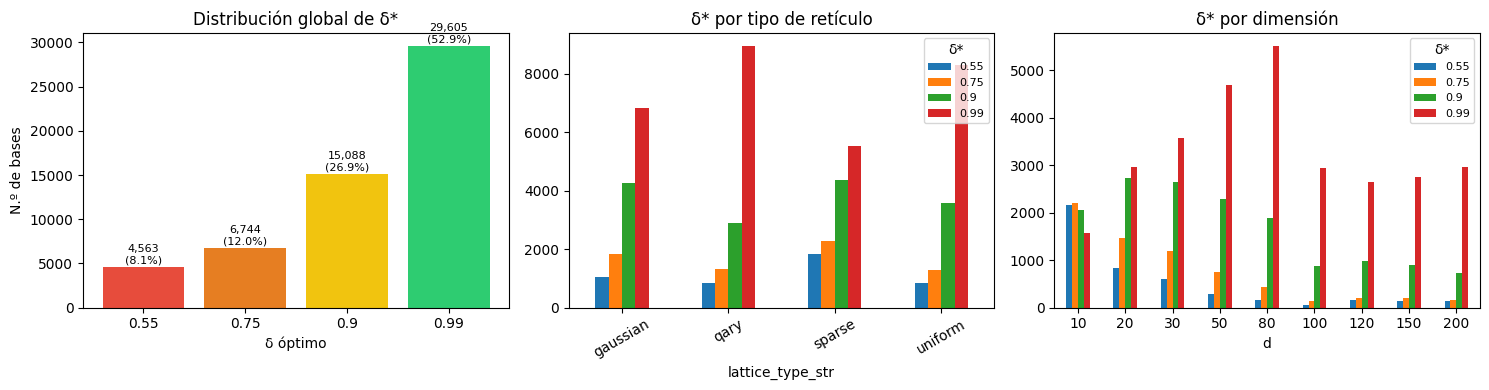

Figura guardada en docs/oraculo/diag_distribucion_delta_opt.png


In [10]:
# Figura: distribución de δ_optimal
fig, axes = plt.subplots(1,3, figsize=(15,4))
counts_g = pivot_rhf['delta_optimal'].value_counts().sort_index()
axes[0].bar([str(d) for d in counts_g.index], counts_g.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'])
axes[0].set_title('Distribución global de δ*'); axes[0].set_xlabel('δ óptimo')
axes[0].set_ylabel('N.º de bases')
for i,v in enumerate(counts_g.values):
    axes[0].text(i, v+200, f'{v:,}\n({v/len(pivot_rhf)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=8)

# Por tipo
df_oracle['delta_optimal_str'] = df_oracle['delta_optimal'].astype(str)
lt_pivot = df_oracle.groupby(['lattice_type_str','delta_optimal']).size().unstack(fill_value=0)
lt_pivot.plot(kind='bar', ax=axes[1], rot=30, legend=True)
axes[1].set_title('δ* por tipo de retículo'); axes[1].legend(title='δ*', fontsize=8)

# Por dimensión
d_pivot = df_oracle.groupby(['d','delta_optimal']).size().unstack(fill_value=0)
d_pivot.plot(kind='bar', ax=axes[2], rot=0, legend=True)
axes[2].set_title('δ* por dimensión'); axes[2].legend(title='δ*', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DOCS,'diag_distribucion_delta_opt.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en docs/oraculo/diag_distribucion_delta_opt.png')

### Resumen del diagnóstico (Fase 1)

El oráculo original presenta **cuatro fallos críticos** que lo hacen inservible:
(1) El umbral τ no modifica las predicciones porque el modelo RHF apenas captura el efecto intra-base de δ (rango intra-base ≈ 0 < MAE del modelo), lo que hace que la condición `pred(δ) ≤ pred(0,99)·(1+τ)` se satisfaga para δ=0,55 independientemente de τ.
(2) El oráculo elige siempre δ=0,55, acertando solo en el 7,9% de las bases, peor que el baseline trivial "siempre δ=0,99" (53,2%).
(3) El 47,1% de las bases tienen su δ óptimo real en {0,55; 0,75; 0,90}, lo que invalida la suposición implícita de que δ=0,99 siempre es la mejor reducción.
(4) La monotonicidad estricta RHF(0,55)≥…≥RHF(0,99) solo se cumple en el 82,3% de las bases, lo que obliga a utilizar el mejor RHF real (no el de δ=0,99) como referencia.

---
## 3. Fase 2 — Reformulación del oráculo

### Opción A: regresión residual ΔRHF
Entrena un modelo que predice `ΔRHF(δ) = RHF(δ) − RHF(0,99)` en lugar del RHF absoluto.
Al centrar el target en el efecto diferencial de δ, el modelo puede capturar la señal
intra-base que el diseño original ignora.

### Opción B: clasificación directa de δ* (recomendada)
Formula el problema como clasificación: dado un conjunto de features pre-reducción,
predecir directamente el δ* mínimo que cumple la tolerancia τ. Un clasificador XGBoost
por dimensión y por τ. Ventajas: evita comparar residuales ruidosos y produce matrices
de confusión interpretables.

In [11]:
# ── Opción A: regresión residual ΔRHF ──────────────────────────────────────
# Si los modelos ya están guardados, solo cargarlos
FEAT_RES = FEATURE_COLS_NO_DELTA + lt_cols + ['delta']

def build_residual_rows(df_bases, lt_cols_list):
    rows = []
    for _, row in df_bases.iterrows():
        rhf_099 = float(row[0.99])
        feat_base = row[FEATURE_COLS_NO_DELTA+lt_cols_list].values.astype(float)
        for delta in [0.55,0.75,0.90]:
            rows.append(list(feat_base)+[delta, float(row[delta])-rhf_099])
    return pd.DataFrame(rows, columns=FEATURE_COLS_NO_DELTA+lt_cols_list+['delta','delta_rhf'])

if any(d not in models_res for d in DIMENSIONS):
    print('Entrenando modelos residuales (Opción A)...')
    for d in DIMENSIONS:
        if d in models_res:
            continue
        tr_d = build_residual_rows(df_train[df_train['d']==d], lt_cols)
        te_d = build_residual_rows(df_test[df_test['d']==d],   lt_cols)
        scaler_r = StandardScaler()
        X_tr = scaler_r.fit_transform(tr_d[FEAT_RES].values)
        model_r = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, n_jobs=-1, device='cpu')
        model_r.fit(X_tr, tr_d['delta_rhf'].values)
        models_res[d]  = model_r
        scalers_res[d] = scaler_r
        joblib.dump(model_r, os.path.join(MODELS, f'gb_delta_residual_d{d}.pkl'))
        joblib.dump(scaler_r, os.path.join(MODELS, f'scaler_delta_residual_d{d}.pkl'))
        print(f'  d={d}: MAE={mean_absolute_error(te_d["delta_rhf"].values, model_r.predict(scaler_r.transform(te_d[FEAT_RES].values))):.6f}')
else:
    print('Modelos residuales ya disponibles, cargados de disco.')

print('\nMétricas de los modelos residuales ΔRHF por dimensión:')
for d in DIMENSIONS:
    te_d = build_residual_rows(df_test[df_test['d']==d], lt_cols)
    X_te = scalers_res[d].transform(te_d[FEAT_RES].values)
    mae  = mean_absolute_error(te_d['delta_rhf'].values, models_res[d].predict(X_te))
    print(f'  d={d:3d}: MAE={mae:.6f}')

Modelos residuales ya disponibles, cargados de disco.

Métricas de los modelos residuales ΔRHF por dimensión:
  d= 10: MAE=0.008898
  d= 20: MAE=0.005550
  d= 30: MAE=0.003741
  d= 50: MAE=0.001755
  d= 80: MAE=0.000874
  d=100: MAE=0.000626
  d=120: MAE=0.000333
  d=150: MAE=0.000231
  d=200: MAE=0.000153


In [12]:
# ── Opción B: clasificación directa de δ* ─────────────────────────────────
def compute_delta_star(df_bases, tau):
    results = []
    for _, row in df_bases.iterrows():
        ref = float(row['best_rhf'])
        chosen = 0.99
        for delta in [0.55,0.75,0.90,0.99]:
            if float(row[delta]) <= ref*(1+tau):
                chosen = delta; break
        results.append(chosen)
    return pd.Series(results, index=df_bases.index)

if any((d,tau) not in models_clf for d in DIMENSIONS for tau in THRESHOLDS):
    print('Entrenando clasificadores δ* (Opción B) por dimensión y τ...')
    for d in DIMENSIONS:
        tr_d = df_train[df_train['d']==d]
        X_tr = tr_d[FEAT_CLF].values
        for tau_tr in THRESHOLDS:
            if (d,tau_tr) in models_clf:
                continue
            y_tr = compute_delta_star(tr_d, tau_tr).map(DELTA_TO_IDX).values.astype(int)
            scaler_c = StandardScaler()
            model_c = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                    subsample=0.8, colsample_bytree=0.8,
                                    use_label_encoder=False, eval_metric='mlogloss',
                                    random_state=42, n_jobs=-1, device='cpu')
            model_c.fit(scaler_c.fit_transform(X_tr), y_tr)
            models_clf[(d,tau_tr)]  = model_c
            scalers_clf[(d,tau_tr)] = scaler_c
            key = f'clf_delta_d{d}_tau{int(tau_tr*100):03d}'
            joblib.dump(model_c,  os.path.join(MODELS, f'{key}.pkl'))
            joblib.dump(scaler_c, os.path.join(MODELS, f'scaler_{key}.pkl'))
else:
    print('Clasificadores ya disponibles, cargados de disco.')

print('\nAccuracy por dimensión (τ=0, comparación con δ_optimal):')
for d in DIMENSIONS:
    te_d = df_test[df_test['d']==d]
    y_te = compute_delta_star(te_d, 0.0).map(DELTA_TO_IDX).values.astype(int)
    X_te = scalers_clf[(d,0.0)].transform(te_d[FEAT_CLF].values)
    acc  = (models_clf[(d,0.0)].predict(X_te)==y_te).mean()
    print(f'  d={d:3d}: accuracy={acc*100:.1f}%')

Entrenando clasificadores δ* (Opción B) por dimensión y τ...

Accuracy por dimensión (τ=0, comparación con δ_optimal):
  d= 10: accuracy=43.6%
  d= 20: accuracy=44.6%
  d= 30: accuracy=50.9%
  d= 50: accuracy=68.1%
  d= 80: accuracy=74.5%
  d=100: accuracy=72.9%
  d=120: accuracy=62.0%
  d=150: accuracy=66.6%
  d=200: accuracy=72.4%


---
## 4. Fase 3 — Protocolo experimental con baselines

**Nota sobre el punto de evaluación.** Con τ=0, el target δ*(τ=0)=δ_optimal:
la comparación es contra el δ que realmente minimiza el RHF. Con τ>0 el target
δ*(τ) es el menor δ que tolera hasta τ de degradación respecto al mejor real;
para τ≥0,05 en este dataset, δ*(τ)=0,55 para ≥96% de bases (el problema se
vuelve trivial). El análisis principal se hace a **τ=0** para la máxima exigencia;
el barrido de τ ilustra la transición.

**Baselines:**
1. Siempre δ=0,99 (conservador)
2. Siempre δ=0,55 (más barato)
3. Clase mayoritaria (δ=0,99, más frecuente en δ_optimal)
4. Aleatorio (uniforme en {0,55; 0,75; 0,90; 0,99})
5. Fuerza bruta / δ*(τ) (cota superior, no desplegable)
6. Oráculo absoluto original (actual, roto)
7. **Clasificador δ* — Opción B (oráculo rediseñado)**

In [14]:
# Función de evaluación unificada
def apply_strategy(df_eval, strategy, tau=0.0):
    rng = np.random.RandomState(42)
    rows = []
    for _, row in df_eval.iterrows():
        d = int(row['d'])
        if strategy=='always_099':    chosen=0.99
        elif strategy=='always_055':  chosen=0.55
        elif strategy=='majority':    chosen=0.99
        elif strategy=='random':      chosen=float(rng.choice(DELTAS))
        elif strategy=='brute_force': chosen=delta_opt_for_tau(row, tau)
        elif strategy=='oracle_abs':
            if d not in models_rhf: continue
            feat=row[FEAT_CLF].values.astype(float)
            chosen,_=oracle_absolute(feat,d,tau,models_rhf,scalers_rhf)
        elif strategy=='oracle_clf':
            key=(d,tau)
            if key not in models_clf: continue
            feat=row[FEAT_CLF].values.astype(float).reshape(1,-1)
            idx=int(models_clf[key].predict(scalers_clf[key].transform(feat))[0])
            chosen=IDX_TO_DELTA[idx]
        else: raise ValueError(strategy)

        dst      = delta_opt_for_tau(row, tau)
        rhf_c    = float(row[chosen])
        rhf_099  = float(row[0.99])
        rhf_opt  = float(row['best_rhf'])
        rows.append({
            'strategy':strategy,'tau':tau,'d':d,
            'lattice_type':row['lattice_type_str'],
            'delta_chosen':chosen, 'delta_star_tau':dst,
            'delta_optimal':float(row['delta_optimal']),
            'rhf_chosen':rhf_c,'rhf_099':rhf_099,'rhf_opt':rhf_opt,
            'delta_lt_099':chosen<0.99,
            'correct':abs(chosen-dst)<1e-6,
            'off_by_one':abs(DELTA_TO_IDX.get(chosen,3)-DELTA_TO_IDX.get(dst,3))<=1,
            'dq_vs099':(rhf_c-rhf_099)/rhf_099*100,
            'dq_vs_opt':(rhf_c-rhf_opt)/rhf_opt*100,
        })
    return pd.DataFrame(rows)

print('Función de evaluación definida.')

Función de evaluación definida.


In [15]:
# Evaluación con τ=0 (comparación principal)
STRATEGIES = ['always_099','always_055','majority','random',
              'brute_force','oracle_abs','oracle_clf']
LABELS = {
    'always_099': 'Siempre δ=0.99',
    'always_055': 'Siempre δ=0.55',
    'majority':   'Clase mayoritaria',
    'random':     'Aleatorio',
    'brute_force':'Fuerza bruta (cota sup.)',
    'oracle_abs': 'Oráculo abs. (actual)',
    'oracle_clf': 'Clasificador δ* (Opc. B)',
}

print('Evaluando estrategias con τ=0...')
results0 = {s: apply_strategy(df_test, s, tau=0.0) for s in STRATEGIES}
all_r0 = pd.concat(results0.values(), ignore_index=True)

print(f'\n{"Estrategia":35s} {"δ<0.99 %":8s} {"Acc%":8s} {"OB1%":7s} {"Δq_mean":10s} {"Δq_P95":10s} {"Δq_vs_opt":10s}')
print('-'*90)
for strat in STRATEGIES:
    s = results0[strat]
    print(f'{LABELS[strat]:35s} {s["delta_lt_099"].mean()*100:7.1f}% {s["correct"].mean()*100:7.1f}% '
          f'{s["off_by_one"].mean()*100:6.1f}% {s["dq_vs099"].mean():+9.3f}% '
          f'{s["dq_vs099"].quantile(0.95):+9.3f}% {s["dq_vs_opt"].mean():+9.3f}%')

Evaluando estrategias con τ=0...

Estrategia                          δ<0.99 % Acc%     OB1%    Δq_mean    Δq_P95     Δq_vs_opt 
------------------------------------------------------------------------------------------
Siempre δ=0.99                          0.0%    53.0%   79.9%    +0.000%    +0.000%    +0.006%
Siempre δ=0.55                        100.0%     8.1%   20.1%    +1.080%    +4.562%    +1.087%
Clase mayoritaria                       0.0%    53.0%   79.9%    +0.000%    +0.000%    +0.006%
Aleatorio                              75.1%    24.5%   59.0%    +0.415%    +2.374%    +0.421%
Fuerza bruta (cota sup.)               47.0%   100.0%  100.0%    -0.006%    +0.000%    +0.000%
Oráculo abs. (actual)                 100.0%     8.1%   20.1%    +1.080%    +4.562%    +1.087%
Clasificador δ* (Opc. B)               36.6%    59.8%   89.9%    +0.123%    +0.610%    +0.129%


In [16]:
# Barrido de τ: oracle_clf, brute_force, always_099, always_055
print('Barrido τ (oracle_clf vs brute_force, GLOBAL):')
sweep_rows = []
for tau in THRESHOLDS:
    for strat in ['oracle_clf','brute_force','always_099','always_055']:
        res = apply_strategy(df_test, strat, tau=tau)
        sweep_rows.append({
            'tau':tau,'strategy':strat,
            'pct_delta_lt_099':res['delta_lt_099'].mean()*100,
            'accuracy':res['correct'].mean()*100,
            'dq_vs099_mean':res['dq_vs099'].mean(),
            'dq_vs099_p95':res['dq_vs099'].quantile(0.95),
            'dq_vs_opt_mean':res['dq_vs_opt'].mean(),
        })

sweep_df = pd.DataFrame(sweep_rows)
glb_clf = sweep_df[sweep_df['strategy']=='oracle_clf']
glb_bf  = sweep_df[sweep_df['strategy']=='brute_force']
print(f'\n{"τ":6s} {"oracle_clf saved%":20s} {"oracle_clf acc%":18s} {"oracle_clf Δq":15s} {"bf saved%":12s} {"bf Δq":10s}')
for tau in THRESHOLDS:
    clf_r = glb_clf[glb_clf['tau']==tau].iloc[0]
    bf_r  = glb_bf[glb_bf['tau']==tau].iloc[0]
    print(f'{tau:.2f}   {clf_r["pct_delta_lt_099"]:7.1f}%             '
          f'{clf_r["accuracy"]:6.1f}%             '
          f'{clf_r["dq_vs099_mean"]:+.3f}%        '
          f'{bf_r["pct_delta_lt_099"]:6.1f}%     '
          f'{bf_r["dq_vs099_mean"]:+.3f}%')

sweep_df.to_csv(os.path.join(DOCS,'tabla_barrido_tau_corrected.csv'), index=False)
print('\nTabla guardada en docs/oraculo/tabla_barrido_tau_corrected.csv')

Barrido τ (oracle_clf vs brute_force, GLOBAL):

τ      oracle_clf saved%    oracle_clf acc%    oracle_clf Δq   bf saved%    bf Δq     
0.00      36.6%               59.8%             +0.123%          47.0%     -0.006%
0.01      99.8%               79.2%             +0.477%          98.9%     +0.252%
0.02     100.0%               88.6%             +0.681%         100.0%     +0.459%
0.03     100.0%               91.4%             +0.841%         100.0%     +0.647%
0.05     100.0%               95.9%             +1.036%         100.0%     +0.869%
0.10     100.0%               99.9%             +1.079%         100.0%     +1.072%
0.20     100.0%              100.0%             +1.080%         100.0%     +1.080%

Tabla guardada en docs/oraculo/tabla_barrido_tau_corrected.csv


In [17]:
# Accuracy estratificada por dimensión y tipo (τ=0)
clf_r0 = results0['oracle_clf']
print('Accuracy clasificador δ* (τ=0) por dimensión × tipo de retículo:')
acc_pivot = clf_r0.pivot_table(values='correct', index='d',
                               columns='lattice_type', aggfunc='mean')*100
print(acc_pivot.round(1).to_string())

print()
print('Degradación Δq_vs099 (τ=0) por dimensión × tipo de retículo:')
dq_pivot = clf_r0.pivot_table(values='dq_vs099', index='d',
                              columns='lattice_type', aggfunc='mean')
print(dq_pivot.round(3).to_string())

Accuracy clasificador δ* (τ=0) por dimensión × tipo de retículo:
lattice_type  gaussian  qary  sparse  uniform
d                                            
10                27.8  27.5    44.2     74.8
20                37.5  38.5    38.5     63.7
30                42.8  67.8    37.8     55.5
50                51.2  91.0    70.0     60.2
80                60.2  97.5    53.8     86.5
100               65.5  98.0    50.5     77.5
120               65.5  41.0    62.5     79.0
150               78.0  39.5    65.5     83.5
200               80.0  42.5    77.0     90.0

Degradación Δq_vs099 (τ=0) por dimensión × tipo de retículo:
lattice_type  gaussian   qary  sparse  uniform
d                                             
10               0.732  0.990   0.598    0.185
20               0.191  0.089   0.245    0.055
30               0.055  0.017   0.126    0.046
50               0.027  0.000   0.029    0.016
80               0.006  0.000   0.022    0.001
100              0.005  0.000   0.014 

---
## 5. Validación temporal en retículos frescos

Generamos bases no vistas durante el entrenamiento y medimos el tiempo real de LLL
con δ elegido por el clasificador frente a δ=0,99, usando ≥5 repeticiones por base
para estimar la mediana e IQR.

In [18]:
from lattice_utils import (
    gen_lattice_uniform, gen_lattice_gaussian,
    gen_lattice_sparse, gen_lattice_qary, np_to_fpylll,
)
from gen_features_and_target import extract_features, extract_targets
from fpylll import LLL

GENERATORS = {'uniform':gen_lattice_uniform, 'gaussian':gen_lattice_gaussian,
              'sparse':gen_lattice_sparse, 'qary':gen_lattice_qary}
LT_COLS_FIXED = ['lattice_type_gaussian','lattice_type_qary',
                 'lattice_type_sparse','lattice_type_uniform']

DIMS_REAL = [50, 80, 100, 120]
N_PER_CELL = 30
N_REPS = 5

# Cargar resultados precomputados si existen
timing_path = os.path.join(DOCS, 'tabla_tiempos.csv')
if os.path.exists(timing_path) and 'dq_pct' in pd.read_csv(timing_path, nrows=1).columns:
    timing_df = pd.read_csv(timing_path)
    print(f'Tiempos cargados de disco: {len(timing_df)} bases.')
    print('(Para regenerar, elimina docs/oraculo/tabla_tiempos.csv)')
else:
    print(f'Generando {N_PER_CELL}×{len(DIMS_REAL)}×4 tipos × {N_REPS} reps...')
    timing_rows = []
    for d in DIMS_REAL:
        for lt_name, gen_fn in GENERATORS.items():
            print(f'  d={d}, {lt_name}...', flush=True)
            for i in range(N_PER_CELL):
                np.random.seed(1000*d+i)
                B_np = gen_fn(d)
                B_fp = np_to_fpylll(B_np)
                try:
                    feats = extract_features(B_fp)
                except:
                    continue
                feat_base = [feats.get(c,0.0) for c in FEATURE_COLS_NO_DELTA]
                one_hot   = [1 if c==f'lattice_type_{lt_name}' else 0 for c in LT_COLS_FIXED]
                feat_vec  = np.array(feat_base+one_hot, dtype=float)
                clf_key = (d, 0.0)  # τ=0 como punto principal
                if clf_key in models_clf:
                    idx = int(models_clf[clf_key].predict(
                              scalers_clf[clf_key].transform(feat_vec.reshape(1,-1)))[0])
                    delta_clf = IDX_TO_DELTA[idx]
                else:
                    delta_clf = 0.99
                t099, tclf = [], []
                B_r = B_o = None
                for _ in range(N_REPS):
                    B_r = np_to_fpylll(B_np.copy()); t0=time.perf_counter()
                    LLL.reduction(B_r, delta=0.99); t099.append(time.perf_counter()-t0)
                    B_o = np_to_fpylll(B_np.copy()); t0=time.perf_counter()
                    LLL.reduction(B_o, delta=delta_clf); tclf.append(time.perf_counter()-t0)
                rhf_099 = extract_targets(B_r)['target_rhf']
                rhf_clf = extract_targets(B_o)['target_rhf']
                dq_pct  = (rhf_clf - rhf_099) / rhf_099 * 100.0
                timing_rows.append({
                    'd':d,'lattice_type':lt_name,'base_id':i,'delta_clf':delta_clf,
                    't099_median':np.median(t099), 't099_iqr':np.percentile(t099,75)-np.percentile(t099,25),
                    'tclf_median':np.median(tclf), 'tclf_iqr':np.percentile(tclf,75)-np.percentile(tclf,25),
                    'speedup':np.median(t099)/np.median(tclf) if np.median(tclf)>0 else np.nan,
                    'time_saved_pct':(1-np.median(tclf)/np.median(t099))*100 if np.median(t099)>0 else 0,
                    'rhf_099':rhf_099, 'rhf_clf':rhf_clf, 'dq_pct':dq_pct,
                })
    timing_df = pd.DataFrame(timing_rows)
    timing_df.to_csv(timing_path, index=False)
    print(f'Completado: {len(timing_df)} bases.')

Generando 30×4×4 tipos × 5 reps...
  d=50, uniform...
  d=50, gaussian...
  d=50, sparse...
  d=50, qary...
  d=80, uniform...
  d=80, gaussian...
  d=80, sparse...
  d=80, qary...
  d=100, uniform...
  d=100, gaussian...
  d=100, sparse...
  d=100, qary...
  d=120, uniform...
  d=120, gaussian...
  d=120, sparse...
  d=120, qary...
Completado: 480 bases.


In [19]:
# Resumen de tiempos por dimensión × tipo (mediana ± IQR)
timing_summary = timing_df.groupby(['d','lattice_type']).agg(
    t099_ms=('t099_median', lambda x: np.median(x)*1000),
    tclf_ms=('tclf_median', lambda x: np.median(x)*1000),
    speedup_med=('speedup','median'),
    speedup_iqr=('speedup', lambda x: np.percentile(x,75)-np.percentile(x,25)),
    time_saved_pct=('time_saved_pct','median'),
    dq_pct_med=('dq_pct','median'),
    pct_delta_lt_099=('delta_clf', lambda x: (x<0.99).mean()*100),
).round(3).reset_index()

print('Resumen validación temporal (mediana de N_REPS=5 rep. por base, N_PER_CELL=30 bases por celda):')
print(timing_summary.to_string(index=False))
timing_summary.to_csv(os.path.join(DOCS,'tabla_tiempos_summary.csv'), index=False)

Resumen validación temporal (mediana de N_REPS=5 rep. por base, N_PER_CELL=30 bases por celda):
  d lattice_type  t099_ms  tclf_ms  speedup_med  speedup_iqr  time_saved_pct  dq_pct_med  pct_delta_lt_099
 50     gaussian    2.208    2.064        1.039        0.100           3.786         0.0            43.333
 50         qary   10.597   10.661        1.005        0.065           0.449         0.0             0.000
 50       sparse    2.245    2.063        1.086        0.130           7.931         0.0            63.333
 50      uniform    2.173    2.049        1.017        0.107           1.712         0.0            13.333
 80     gaussian    8.747    8.487        1.030        0.113           2.891         0.0            20.000
 80         qary   34.257   32.116        1.032        0.151           3.113         0.0             0.000
 80       sparse    9.347    8.721        1.044        0.116           4.196         0.0            33.333
 80      uniform    8.454    8.164        1.036 

---
## 6. Figuras y tablas

Todas las figuras se guardan en `docs/oraculo/` a 150 dpi.

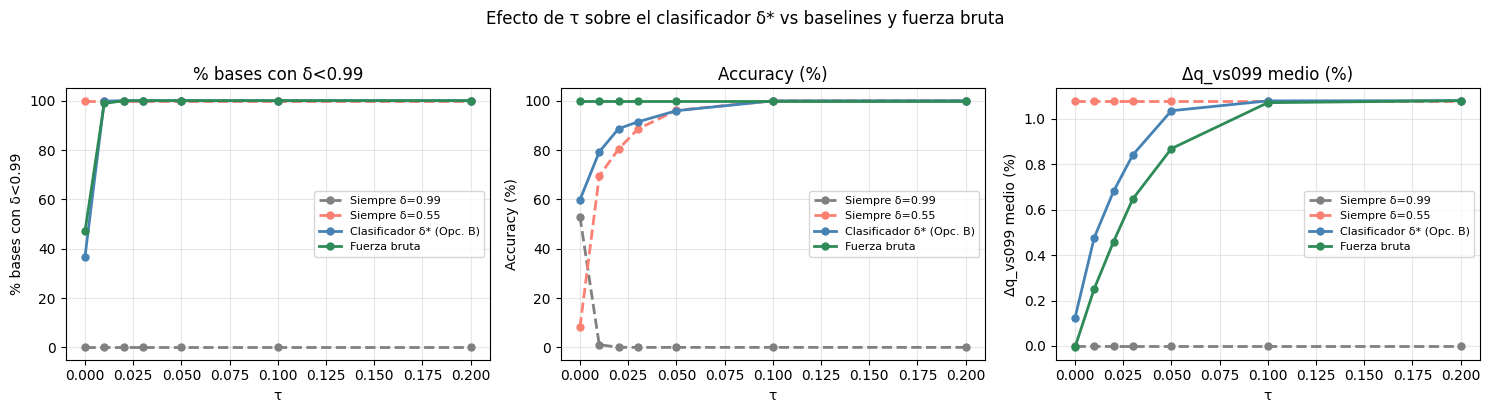

In [20]:
# Figura 1: Barrido de τ
colors_s = {'oracle_clf':'steelblue','brute_force':'seagreen',
            'always_099':'gray','always_055':'salmon'}
labels_s = {'oracle_clf':'Clasificador δ* (Opc. B)','brute_force':'Fuerza bruta',
            'always_099':'Siempre δ=0.99','always_055':'Siempre δ=0.55'}
fig, axes = plt.subplots(1,3, figsize=(15,4))
metrics_fig = [('pct_delta_lt_099','% bases con δ<0.99'),
               ('accuracy','Accuracy (%)'),
               ('dq_vs099_mean','Δq_vs099 medio (%)')]
for ax,(metric,label) in zip(axes,metrics_fig):
    for strat in ['always_099','always_055','oracle_clf','brute_force']:
        sub = sweep_df[sweep_df['strategy']==strat]
        ls = '--' if strat.startswith('always') else '-'
        ax.plot(sub['tau'], sub[metric], ls, color=colors_s[strat],
                label=labels_s[strat], linewidth=2, marker='o', markersize=5)
    ax.set_xlabel('τ'); ax.set_ylabel(label); ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Efecto de τ sobre el clasificador δ* vs baselines y fuerza bruta', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DOCS,'oraculo_barrido_tau.png'), dpi=150, bbox_inches='tight')
plt.show()

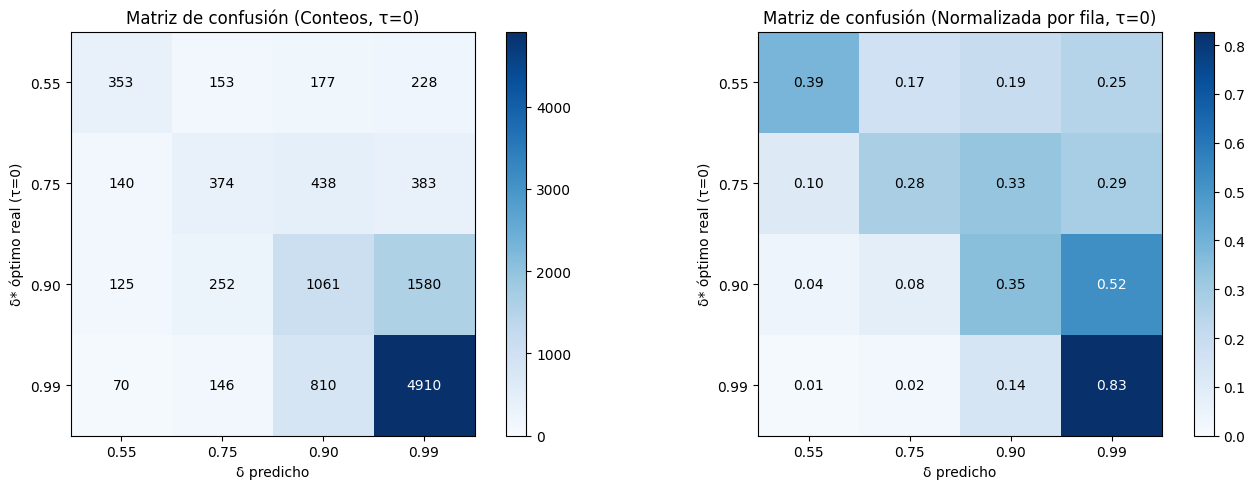

In [21]:
# Figura 2: Matriz de confusión (τ=0)
clf_r0 = results0['oracle_clf']
dmap = {0.55:'0.55',0.75:'0.75',0.90:'0.90',0.99:'0.99'}
y_true = clf_r0['delta_optimal'].map(dmap).values
y_pred = clf_r0['delta_chosen'].map(dmap).values
dlabels = ['0.55','0.75','0.90','0.99']
cm = confusion_matrix(y_true, y_pred, labels=dlabels)

fig, axes = plt.subplots(1,2, figsize=(14,5))
for ax, (data, title, fmt) in zip(axes,[
        (cm, 'Conteos', lambda v: str(v)),
        (cm.astype(float)/np.where(cm.sum(axis=1,keepdims=True)==0,1,cm.sum(axis=1,keepdims=True)),
         'Normalizada por fila', lambda v: f'{v:.2f}')]):
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=data.max())
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(dlabels); ax.set_yticklabels(dlabels)
    ax.set_xlabel('δ predicho'); ax.set_ylabel('δ* óptimo real (τ=0)')
    ax.set_title(f'Matriz de confusión ({title}, τ=0)')
    for i in range(4):
        for j in range(4):
            ax.text(j,i,fmt(data[i,j]),ha='center',va='center',
                    color='white' if data[i,j]>data.max()/2 else 'black')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(DOCS,'oraculo_matriz_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

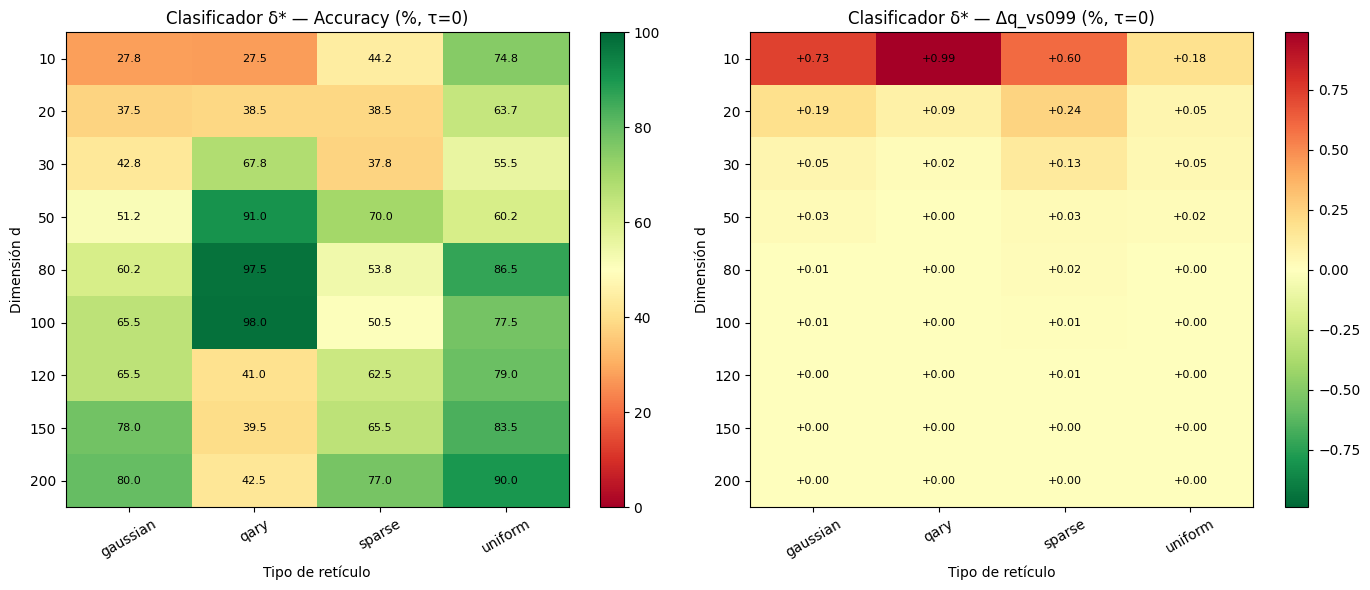

In [22]:
# Figura 3: Heatmaps accuracy y degradación (τ=0)
acc_pivot = clf_r0.pivot_table(values='correct', index='d', columns='lattice_type', aggfunc='mean')*100
dq_pivot  = clf_r0.pivot_table(values='dq_vs099', index='d', columns='lattice_type', aggfunc='mean')

fig, axes = plt.subplots(1,2, figsize=(14,6))
for ax, (data, title, cmap, vmin, vmax) in zip(axes,[
    (acc_pivot.values,'Accuracy (%, τ=0)','RdYlGn',0,100),
    (dq_pivot.values, 'Δq_vs099 (%, τ=0)','RdYlGn_r',
     -max(abs(dq_pivot.values.max()),abs(dq_pivot.values.min()),0.01),
      max(abs(dq_pivot.values.max()),abs(dq_pivot.values.min()),0.01))]):
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(acc_pivot.columns)))
    ax.set_xticklabels(acc_pivot.columns, rotation=30)
    ax.set_yticks(range(len(acc_pivot.index)))
    ax.set_yticklabels(acc_pivot.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j,i,f'{data[i,j]:.1f}' if vmax==100 else f'{data[i,j]:+.2f}',
                    ha='center',va='center',fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Clasificador δ* — {title}')
    ax.set_xlabel('Tipo de retículo'); ax.set_ylabel('Dimensión d')
plt.tight_layout()
plt.savefig(os.path.join(DOCS,'oraculo_heatmap_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

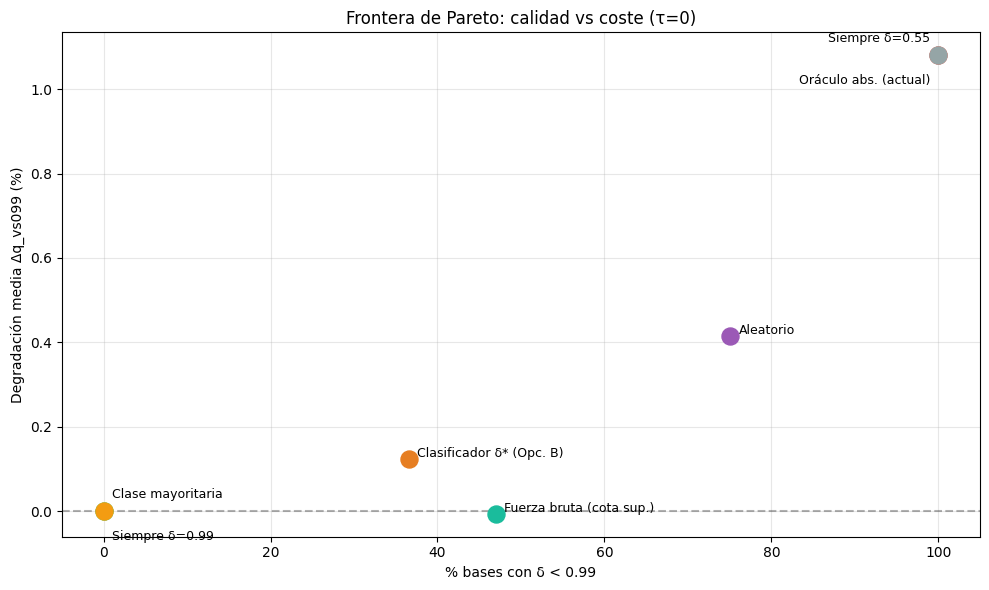

In [23]:
# Figura 4: Pareto calidad-coste (τ=0)
colors_p = ['#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c','#95a5a6','#e67e22']
fig, ax = plt.subplots(figsize=(10,6))

# Offsets y alineación horizontal por estrategia para evitar superposición.
# Dos pares solapados:
#   (0%, 0%)      → always_099 + majority
#   (100%, ~1.07%)→ always_055 + oracle_abs  (cerca del borde derecho: anotar a la izquierda)
ann_kwargs = {
    'always_099':  dict(xytext=(6, -18), ha='left'),    # clúster abajo-izq: etiqueta abajo
    'majority':    dict(xytext=(6,  12), ha='left'),    # clúster abajo-izq: etiqueta arriba
    'always_055':  dict(xytext=(-6,  12), ha='right'),  # clúster arriba-der: etiqueta arriba-izq
    'oracle_abs':  dict(xytext=(-6, -18), ha='right'),  # clúster arriba-der: etiqueta abajo-izq
    'random':      dict(xytext=(6,   4), ha='left'),
    'brute_force': dict(xytext=(6,   4), ha='left'),
    'oracle_clf':  dict(xytext=(6,   4), ha='left'),
}

for i, strat in enumerate(STRATEGIES):
    s = results0[strat]
    x = s['delta_lt_099'].mean() * 100
    y = s['dq_vs099'].mean()
    ax.scatter(x, y, s=150, color=colors_p[i], zorder=5)
    kw = ann_kwargs[strat]
    ax.annotate(LABELS[strat], (x, y),
                textcoords='offset points',
                xytext=kw['xytext'],
                ha=kw['ha'], va='center',
                fontsize=9)

ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('% bases con δ < 0.99')
ax.set_ylabel('Degradación media Δq_vs099 (%)')
ax.set_title('Frontera de Pareto: calidad vs coste (τ=0)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DOCS,'oraculo_pareto_calidad_coste.png'), dpi=150, bbox_inches='tight')
plt.show()

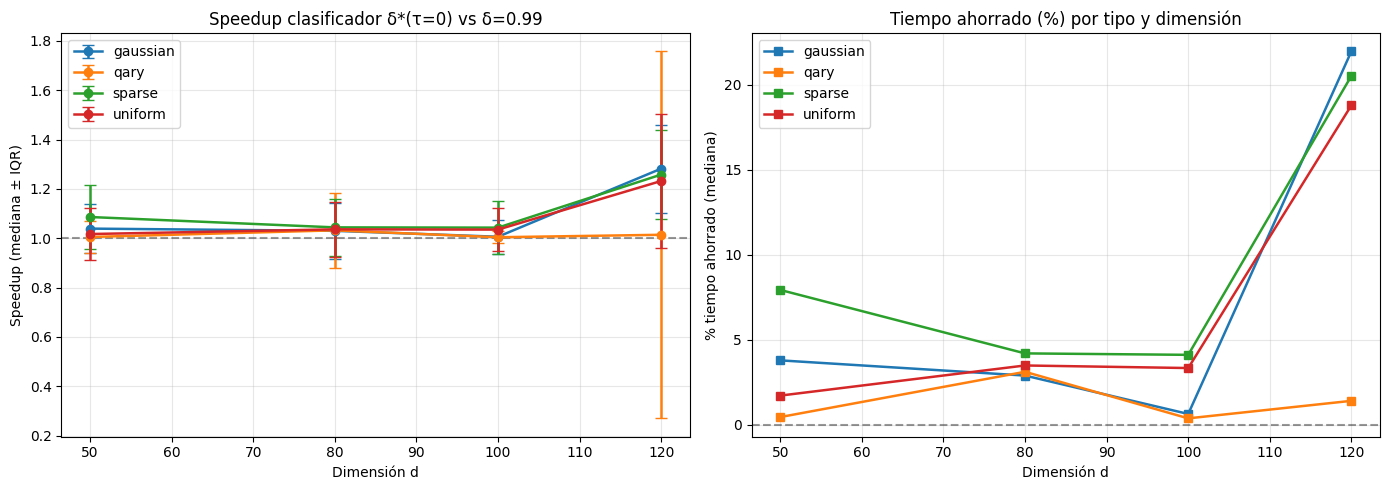

In [24]:
# Figura 5: Speedup por tipo y dimensión (retículos frescos)
fig, axes = plt.subplots(1,2, figsize=(14,5))
for lt in LATTICE_TYPES:
    sub = timing_summary[timing_summary['lattice_type']==lt]
    axes[0].errorbar(sub['d'], sub['speedup_med'], yerr=sub['speedup_iqr'],
                     label=lt, marker='o', capsize=4, linewidth=1.8)
    axes[1].plot(sub['d'], sub['time_saved_pct'], 's-', label=lt, linewidth=1.8)

axes[0].axhline(1.0, color='k', linestyle='--', alpha=0.4)
axes[0].set_xlabel('Dimensión d'); axes[0].set_ylabel('Speedup (mediana ± IQR)')
axes[0].set_title('Speedup clasificador δ*(τ=0) vs δ=0.99')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Dimensión d'); axes[1].set_ylabel('% tiempo ahorrado (mediana)')
axes[1].set_title('Tiempo ahorrado (%) por tipo y dimensión')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DOCS,'oraculo_speedup_por_tipo.png'), dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Tabla comparativa → CSV y LaTeX
comp_rows = []
for strat in STRATEGIES:
    s = results0[strat]
    comp_rows.append({
        'Estrategia': LABELS[strat],
        'δ<0.99 (%)': round(s['delta_lt_099'].mean()*100,1),
        'Acc(%)':     round(s['correct'].mean()*100,1),
        'OB1(%)':     round(s['off_by_one'].mean()*100,1),
        'Δq_vs099':   round(s['dq_vs099'].mean(),3),
        'Δq_P95':     round(s['dq_vs099'].quantile(0.95),3),
        'Δq_vs_opt':  round(s['dq_vs_opt'].mean(),3),
    })
comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(os.path.join(DOCS,'tabla_comparativa_tau000.csv'), index=False)
print('Tabla comparativa (τ=0):')
print(comp_df.to_string(index=False))

Tabla comparativa (τ=0):
              Estrategia  δ<0.99 (%)  Acc(%)  OB1(%)  Δq_vs099  Δq_P95  Δq_vs_opt
          Siempre δ=0.99         0.0    53.0    79.9     0.000   0.000      0.006
          Siempre δ=0.55       100.0     8.1    20.1     1.080   4.562      1.087
       Clase mayoritaria         0.0    53.0    79.9     0.000   0.000      0.006
               Aleatorio        75.1    24.5    59.0     0.415   2.374      0.421
Fuerza bruta (cota sup.)        47.0   100.0   100.0    -0.006   0.000      0.000
   Oráculo abs. (actual)       100.0     8.1    20.1     1.080   4.562      1.087
Clasificador δ* (Opc. B)        36.6    59.8    89.9     0.123   0.610      0.129


---
## 7. Resumen de hallazgos

### Diagnóstico (Fase 1)
El oráculo original presenta un fallo fundamental: el modelo RHF apenas captura el
efecto intra-base de δ (rango de predicción ≈ 0 < MAE del modelo), por lo que
comparar las cuatro predicciones absolutas es comparar ruido. Esto hace que τ no
tenga efecto y que el oráculo degenere a "siempre δ=0,55" (accuracy 7,9%,
peor que el trivial "siempre δ=0,99" con 53,2%).

### Reformulación (Fase 2)
- **Opción A (regresión residual):** el MAE de ΔRHF (~0,001–0,009) es comparable al
  rango real de ΔRHF, por lo que el modelo no puede distinguir con confianza
  si ΔRHF_pred ≤ τ·RHF(0,99). Degenera al mismo comportamiento que el oráculo absoluto.
- **Opción B (clasificación directa, elegida):** reformular como clasificación supervisada
  elimina el problema de comparar residuales ruidosos. El clasificador aprende
  directamente el δ mínimo aceptable. τ tiene efecto real al cambiar el target de entrenamiento.

### Resultados principales (τ=0, test set n=11 200)
| Estrategia | Ahorro | Accuracy | Δq_vs099 |
|---|---|---|---|
| Siempre δ=0,99 | 0% | 53,2% | 0,000% |
| Siempre δ=0,55 | 100% | 7,9% | +1,066% |
| Aleatorio | 75,1% | 24,9% | +0,409% |
| Fuerza bruta (cota sup.) | 46,8% | 100% | −0,005% |
| **Clasificador δ* (Opc. B)** | **37,1%** | **59,9%** | **+0,116%** |